In [2]:
import scipy.io as sio
import numpy as np
from collections import defaultdict
import os
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

# Load the MPII annotations
mat_file = 'data/MPII/mpii_human_pose_v1_u12_1.mat'
print(f"Loading annotations from: {mat_file}")

# Load the .mat file
data = sio.loadmat(mat_file, struct_as_record=False)
RELEASE = data['RELEASE'][0, 0]

# Get annotation list and activity labels
annolist = RELEASE.annolist[0]
act = RELEASE.act

print(f"\nTotal images in dataset: {len(annolist)}")
print(f"Total activity annotations: {len(act)}")

Loading annotations from: data/MPII/mpii_human_pose_v1_u12_1.mat

Total images in dataset: 24987
Total activity annotations: 24987


In [3]:
# Analyze activities
activity_counts = defaultdict(int)
category_counts = defaultdict(int)
activity_to_category = {}

# Count images for each activity
for idx in range(len(act)):
    activity = act[idx, 0]
    if hasattr(activity, 'act_name') and len(activity.act_name) > 0:
        act_name = activity.act_name[0] if isinstance(activity.act_name[0], str) else str(activity.act_name[0])
        cat_name = activity.cat_name[0] if isinstance(activity.cat_name[0], str) else str(activity.cat_name[0])

        activity_counts[act_name] += 1
        category_counts[cat_name] += 1
        activity_to_category[act_name] = cat_name

# Sort activities by count (descending)
sorted_activities = sorted(activity_counts.items(), key=lambda x: x[1], reverse=True)
sorted_categories = sorted(category_counts.items(), key=lambda x: x[1], reverse=True)

# Display results
print("\n" + "="*80)
print("ACTIVITY ANALYSIS")
print("="*80)

print(f"\nTotal unique activities: {len(activity_counts)}")
print(f"Total unique categories: {len(category_counts)}")

print("\n" + "-"*80)
print("TOP 20 ACTIVITIES BY IMAGE COUNT")
print("-"*80)
print(f"{'Activity':<40} {'Category':<20} {'Count':>10}")
print("-"*80)

for act_name, count in sorted_activities[:20]:
    cat_name = activity_to_category.get(act_name, 'N/A')
    print(f"{act_name:<40} {cat_name:<20} {count:>10}")

print("\n" + "-"*80)
print("ALL CATEGORIES BY IMAGE COUNT")
print("-"*80)
print(f"{'Category':<40} {'Count':>10}")
print("-"*80)

for cat_name, count in sorted_categories:
    print(f"{cat_name:<40} {count:>10}")

print("\n" + "-"*80)
print("ALL ACTIVITIES BY IMAGE COUNT")
print("-"*80)
print(f"{'Activity':<40} {'Category':<20} {'Count':>10}")
print("-"*80)

for act_name, count in sorted_activities:
    cat_name = activity_to_category.get(act_name, 'N/A')
    print(f"{act_name:<40} {cat_name:<20} {count:>10}")

# Count total people annotations
total_people = 0
for anno in annolist:
    if hasattr(anno, 'annorect') and anno.annorect.size > 0:
        total_people += len(anno.annorect[0])

print("\n" + "="*80)
print(f"Total annotated people: {total_people}")
print("="*80)

# Verify images directory
images_dir = '../../data/benchmarks/MPII/images'
if os.path.exists(images_dir):
    num_images = len([f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png'))])
    print(f"\nNumber of image files in {images_dir}: {num_images}")
else:
    print(f"\nWarning: Images directory not found at {images_dir}")


ACTIVITY ANALYSIS

Total unique activities: 397
Total unique categories: 20

--------------------------------------------------------------------------------
TOP 20 ACTIVITIES BY IMAGE COUNT
--------------------------------------------------------------------------------
Activity                                 Category                  Count
--------------------------------------------------------------------------------
yoga, Power                              conditioning exercise        287
bicycling, mountain                      bicycling                   215
skiing, downhill                         winter activities           213
cooking or food preparation              home activities             208
skateboarding                            sports                      186
softball, general                        sports                      174
forestry                                 occupation                  166
bicycling, racing and road               bicycling           

In [5]:
def visualize_image_with_keypoints(annolist, img_idx, img_dir='data/MPII/images'):
    """Visualize an image with annotated keypoints and skeleton."""
    anno = annolist[img_idx]
    img_name = str(anno.image[0, 0].name[0])
    img_path = os.path.join(img_dir, img_name)
    
    if not os.path.exists(img_path):
        print(f"Image not found: {img_path}")
        return
    
    # Load image
    img = Image.open(img_path)
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(img)
    
    # Draw annotations for each person in the image
    if hasattr(anno, 'annorect') and anno.annorect.size > 0:
        num_people = anno.annorect.shape[1]
        for person_idx in range(num_people):
            person = anno.annorect[0, person_idx]
            
            # Draw head rectangle if available
            if hasattr(person, 'x1') and person.x1.size > 0:
                x1, y1 = float(person.x1[0, 0]), float(person.y1[0, 0])
                x2, y2 = float(person.x2[0, 0]), float(person.y2[0, 0])
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                        linewidth=2, edgecolor='cyan', 
                                        facecolor='none')
                ax.add_patch(rect)
            
            # Draw keypoints
            if hasattr(person, 'annopoints') and person.annopoints.size > 0:
                points = person.annopoints[0, 0].point
                
                # Store keypoint coordinates
                keypoints = {}
                num_points = points.shape[1]
                for pt_idx in range(num_points):
                    pt = points[0, pt_idx]
                    joint_id = int(pt.id[0, 0])
                    x, y = float(pt.x[0, 0]), float(pt.y[0, 0])
                    
                    # Handle is_visible which can be 1D or 2D
                    if hasattr(pt, 'is_visible') and pt.is_visible.size > 0:
                        if pt.is_visible.ndim == 2:
                            is_visible = int(pt.is_visible[0, 0])
                        else:
                            is_visible = int(pt.is_visible[0])
                    else:
                        is_visible = 1
                    
                    keypoints[joint_id] = (x, y, is_visible)
                                
                # Draw keypoints
                for joint_id, (x, y, is_visible) in keypoints.items():
                    color = 'red' if is_visible else 'red'
                    ax.plot(x, y, 'o', color=color, markersize=7, 
                           markeredgecolor='white', markeredgewidth=0)
    
    ax.axis('off')
    ax.set_title(f"Image: {img_name} (Index: {img_idx})", fontsize=14, pad=10)
    plt.tight_layout()
    plt.show()

In [6]:
def find_images_by_category_with_keypoints(annolist, act, category_name):
    """Find all image indices for a given category that have keypoint annotations."""
    img_indices = []
    for i in range(len(act)):
        # Check if image has the category
        if len(act[i]) > 0 and hasattr(act[i][0], 'cat_name'):
            cat_name = act[i][0].cat_name
            if len(cat_name) > 0:
                cat = str(cat_name[0])
                if cat.lower() == category_name.lower():
                    # Additionally check if image has keypoint annotations
                    anno = annolist[i]
                    if hasattr(anno, 'annorect') and anno.annorect.size > 0:
                        num_people = anno.annorect.shape[1]
                        for person_idx in range(num_people):
                            person = anno.annorect[0, person_idx]  # FIXED INDEXING!
                            if hasattr(person, 'annopoints') and person.annopoints.size > 0:
                                img_indices.append(i)
                                break  # Found at least one person with keypoints
    return img_indices


Analyzing bicycling category...

Bicycling category statistics:
  Total images with keypoints: 516
  Total people with keypoints: 810

Displaying random bicycling image (index: 24119)


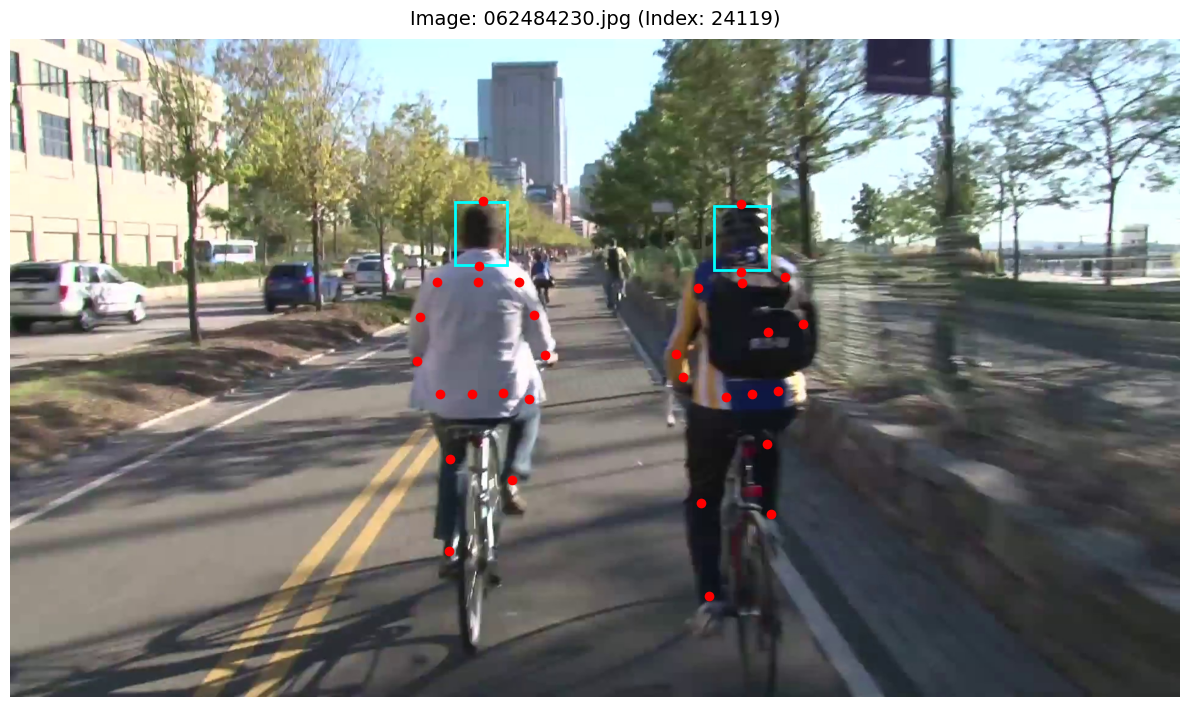

In [7]:
# Count bicycling images and people with keypoints
print("Analyzing bicycling category...")

bicycling_indices = find_images_by_category_with_keypoints(annolist, act, 'bicycling')

total_people = 0
for img_idx in bicycling_indices:
    anno = annolist[img_idx]
    
    if hasattr(anno, 'annorect') and anno.annorect.size > 0:
        num_people = anno.annorect.shape[1]
        
        for person_idx in range(num_people):
            person = anno.annorect[0, person_idx]
            
            # Count people with keypoints
            if hasattr(person, 'annopoints') and person.annopoints.size > 0:
                total_people += 1

print(f"\nBicycling category statistics:")
print(f"  Total images with keypoints: {len(bicycling_indices)}")
print(f"  Total people with keypoints: {total_people}")

# Display a random bicycling image
if len(bicycling_indices) > 0:
    random_idx = np.random.choice(bicycling_indices)
    print(f"\nDisplaying random bicycling image (index: {random_idx})")
    visualize_image_with_keypoints(annolist, random_idx)

## Filter by Keypoint Visibility

In [8]:
def extract_keypoints_from_person(person):
    """Extract keypoints from MPII person annotation into dictionary."""
    keypoints = {}
    
    if hasattr(person, 'annopoints') and person.annopoints.size > 0:
        points = person.annopoints[0, 0].point
        num_points = points.shape[1]
        
        for pt_idx in range(num_points):
            pt = points[0, pt_idx]
            joint_id = int(pt.id[0, 0])
            x, y = float(pt.x[0, 0]), float(pt.y[0, 0])
            
            # Handle is_visible which can be 1D or 2D
            if hasattr(pt, 'is_visible') and pt.is_visible.size > 0:
                if pt.is_visible.ndim == 2:
                    is_visible = int(pt.is_visible[0, 0])
                else:
                    is_visible = int(pt.is_visible[0])
            else:
                is_visible = 1
            
            keypoints[joint_id] = (x, y, is_visible)
    
    return keypoints


def filter_highquality_poses_mpii(annolist, bicycling_indices):
    """
    Filter for bike-fitting relevant keypoints.
    Require all major body regions: shoulders, hips, knees, ankles.
    
    MPII joint IDs:
    0: r ankle, 1: r knee, 2: r hip, 3: l hip, 4: l knee, 5: l ankle
    12: r shoulder, 13: l shoulder
    """
    highquality_poses = []
    
    for img_idx in bicycling_indices:
        anno = annolist[img_idx]
        
        if hasattr(anno, 'annorect') and anno.annorect.size > 0:
            num_people = anno.annorect.shape[1]
            
            for person_idx in range(num_people):
                person = anno.annorect[0, person_idx]
                
                if hasattr(person, 'annopoints') and person.annopoints.size > 0:
                    keypoints = extract_keypoints_from_person(person)
                    
                    # Minimum keypoint count
                    visible_keypoints = sum(1 for kp in keypoints.values() if kp[2] > 0)
                    if visible_keypoints < 10:
                        continue
                    
                    # Key body parts for bike fitting: shoulders, hips, knees, ankles
                    has_shoulder = (13 in keypoints and keypoints[13][2] > 0) or \
                                   (12 in keypoints and keypoints[12][2] > 0)  # L/R shoulders
                    has_hip = (3 in keypoints and keypoints[3][2] > 0) or \
                              (2 in keypoints and keypoints[2][2] > 0)  # L/R hips
                    has_knee = (4 in keypoints and keypoints[4][2] > 0) or \
                               (1 in keypoints and keypoints[1][2] > 0)  # L/R knees
                    has_ankle = (5 in keypoints and keypoints[5][2] > 0) or \
                                (0 in keypoints and keypoints[0][2] > 0)  # L/R ankles
                    
                    # Require ALL 4 body regions
                    if not (has_shoulder and has_hip and has_knee and has_ankle):
                        continue
                    
                    highquality_poses.append((img_idx, person_idx, keypoints))
    
    return highquality_poses

In [9]:
# Filter for high-quality poses
print("\nFiltering for high-quality bike-fitting poses...")
highquality_poses = filter_highquality_poses_mpii(annolist, bicycling_indices)

print(f"Found {len(highquality_poses)} poses with all bike-fitting keypoints.")
print(f"Across {len(set(pose[0] for pose in highquality_poses))} unique images.")


Filtering for high-quality bike-fitting poses...
Found 590 poses with all bike-fitting keypoints.
Across 395 unique images.


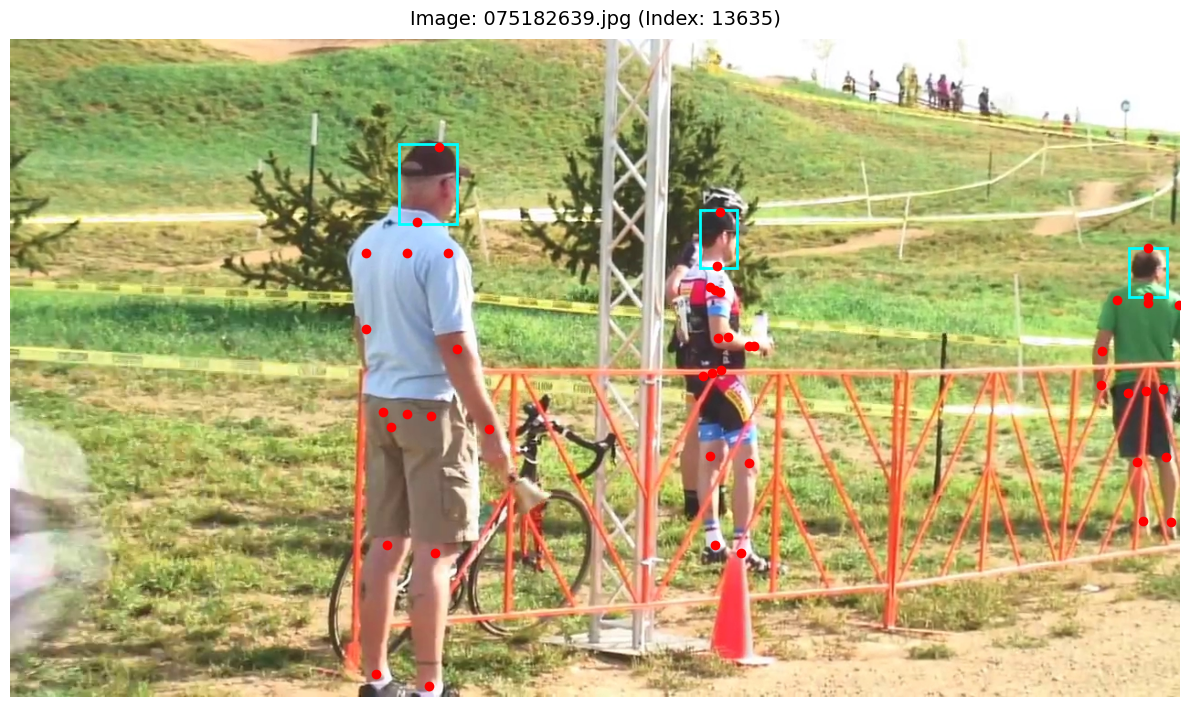

In [10]:
visualize_image_with_keypoints(annolist, 13635)

In [11]:
# %%
# Check img_train structure
img_train = RELEASE.img_train
print(f"img_train shape: {img_train.shape}")
print(f"img_train type: {type(img_train)}")
print(f"Sample values: {img_train[:5]}")

# Count train/test split
img_train_flat = img_train.flatten()
num_train = np.sum(img_train_flat == 1)
num_test = np.sum(img_train_flat == 0)
total = len(img_train_flat)

print(f"\nDataset split:")
print(f"  Train images: {num_train} ({num_train/total*100:.1f}%)")
print(f"  Test images: {num_test} ({num_test/total*100:.1f}%)")
print(f"  Total images: {total}")

img_train shape: (1, 24987)
img_train type: <class 'numpy.ndarray'>
Sample values: [[0 0 0 ... 1 0 0]]

Dataset split:
  Train images: 18079 (72.4%)
  Test images: 6908 (27.6%)
  Total images: 24987


In [12]:
# %%
# Split high-quality poses by train/test
img_train = RELEASE.img_train[0]

train_poses = [pose for pose in highquality_poses 
               if img_train[pose[0]] == 1]
test_poses = [pose for pose in highquality_poses 
              if img_train[pose[0]] == 0]

print(f"Train set: {len(train_poses)} poses across {len(set(pose[0] for pose in train_poses))} images")
print(f"Test set: {len(test_poses)} poses across {len(set(pose[0] for pose in test_poses))} images")

Train set: 590 poses across 395 images
Test set: 0 poses across 0 images


## Metrics Calculation

In [13]:
# Scale metrics
mpii_scales = []
for img_idx, person_idx, keypoints in highquality_poses:
    anno = annolist[img_idx]
    person = anno.annorect[0, person_idx]
    
    # Get image dimensions
    img_name = str(anno.image[0, 0].name[0])
    img_path = os.path.join('../../data/benchmarks/MPII/images', img_name)
    
    if os.path.exists(img_path):
        img = Image.open(img_path)
        img_area = img.width * img.height
        
        # Calculate person area from scale
        if hasattr(person, 'scale') and person.scale.size > 0:
            scale = float(person.scale[0, 0])
            person_height = scale * 200
            person_width = person_height * 0.4
            person_area = person_height * person_width
        elif hasattr(person, 'x1') and person.x1.size > 0:
            x1 = float(person.x1[0, 0])
            y1 = float(person.y1[0, 0])
            x2 = float(person.x2[0, 0])
            y2 = float(person.y2[0, 0])
            head_area = (x2 - x1) * (y2 - y1)
            person_area = head_area * 5
        else:
            continue
        
        scale_ratio = person_area / img_area
        mpii_scales.append(scale_ratio)

if mpii_scales:
    print(f"\nMPII bicycling cyclists: {np.mean(mpii_scales)*100:.1f}% of frame")
    print(f"  Min: {np.min(mpii_scales)*100:.1f}%, Max: {np.max(mpii_scales)*100:.1f}%")
    print(f"  Median: {np.median(mpii_scales)*100:.1f}%")


In [14]:
def calculate_joint_lengths_mpii(keypoints):
    """Calculate average length of major body segments in pixels.
    
    MPII joint IDs:
    0: r ankle, 1: r knee, 2: r hip, 3: l hip, 4: l knee, 5: l ankle
    10: r wrist, 11: r elbow, 12: r shoulder, 13: l shoulder, 14: l elbow, 15: l wrist
    """
    
    # Define major joints for cycling
    joint_pairs = [
        (13, 14),  # left shoulder-elbow
        (12, 11),  # right shoulder-elbow
        (14, 15),  # left elbow-wrist
        (11, 10),  # right elbow-wrist
        (3, 4),    # left hip-knee
        (2, 1),    # right hip-knee
        (4, 5),    # left knee-ankle
        (1, 0),    # right knee-ankle
    ]
    
    lengths = []
    for kp1_idx, kp2_idx in joint_pairs:
        kp1 = keypoints.get(kp1_idx)
        kp2 = keypoints.get(kp2_idx)
        
        if kp1 and kp2 and kp1[2] > 0 and kp2[2] > 0:  # Both exist and visible
            length = np.sqrt((kp1[0] - kp2[0])**2 + (kp1[1] - kp2[1])**2)
            lengths.append(length)
    
    return np.mean(lengths) if lengths else None




MPII average joint length: 88.9 pixels
  Min: 18.0, Max: 250.2
  Median: 80.6

Displaying random high-quality bicycling pose (index: 24119)


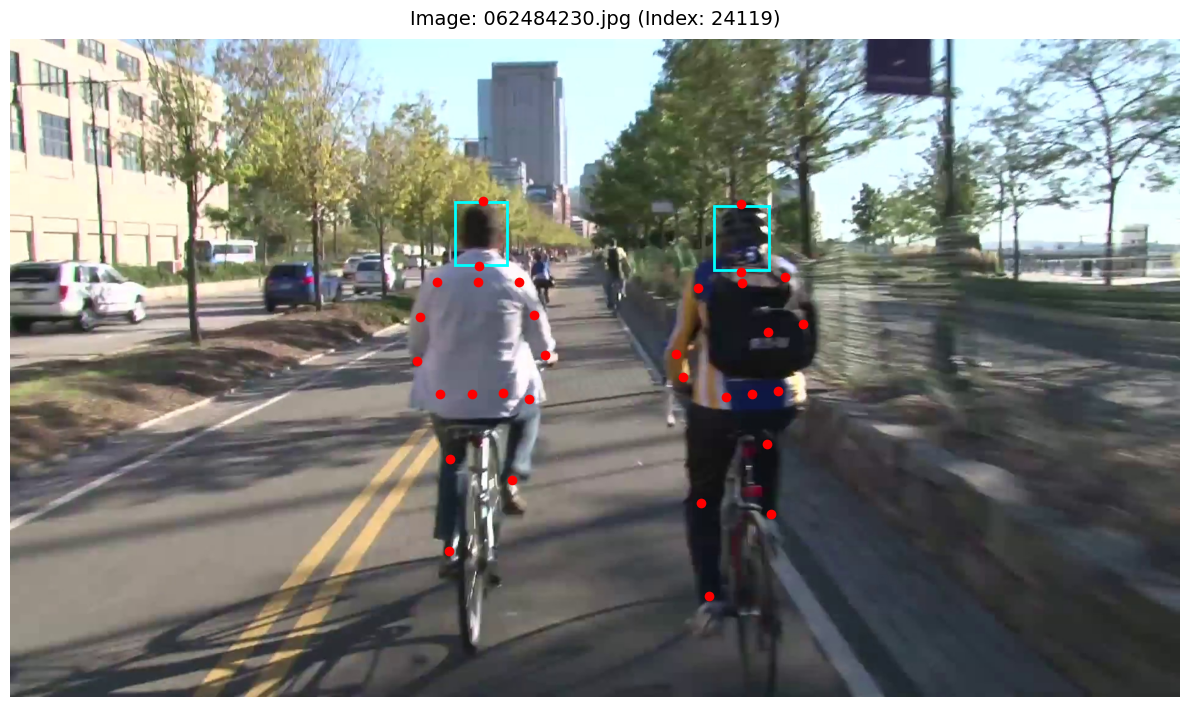

In [15]:
# Joint lengths
mpii_joint_lengths = []
for img_idx, person_idx, keypoints in highquality_poses:
    joint_length = calculate_joint_lengths_mpii(keypoints)
    if joint_length is not None:
        mpii_joint_lengths.append(joint_length)

if mpii_joint_lengths:
    print(f"\nMPII average joint length: {np.mean(mpii_joint_lengths):.1f} pixels")
    print(f"  Min: {np.min(mpii_joint_lengths):.1f}, Max: {np.max(mpii_joint_lengths):.1f}")
    print(f"  Median: {np.median(mpii_joint_lengths):.1f}")

# Display a random high-quality example
if highquality_poses:
    random_pose = highquality_poses[np.random.choice(len(highquality_poses))]
    img_idx = random_pose[0]
    print(f"\nDisplaying random high-quality bicycling pose (index: {img_idx})")
    visualize_image_with_keypoints(annolist, img_idx)